In [ ]:
from google.colab import drive
drive.mount = '/content/AI-Generated Scientific Text Dataset (AIGTxt).xlsx'


In [ ]:
import pandas as pd

file_path = '/content/AI-Generated Scientific Text Dataset (AIGTxt).xlsx'
df = pd.read_excel(file_path)

df = df[['Human-Generated', 'ChatGPT-Generated']]


In [ ]:
import re

def preprocess_scientific_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\[\d+(?:,\s*\d+)*\]', '', text)
    text = re.sub(r'\[\d+-\d+\]', '', text)
    text = re.sub(r'\([A-Z][a-z]+, \d{4}\)', '', text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    return text
    df['Human-Generated'] = df['Human-Generated'].apply(preprocess_scientific_text)
    df['ChatGPT-Generated'] = df['ChatGPT-Generated'].apply(preprocess_scientific_text)

In [ ]:
df = df[(df['Human-Generated'] != "") & (df['ChatGPT-Generated'] != "")]

human_texts = df['Human-Generated'].tolist()
ai_texts = df['ChatGPT-Generated'].tolist()

texts = human_texts + ai_texts
labels = [0] * len(human_texts) + [1] * len(ai_texts)

print("--- HUMAN GENERATED (Label 0) ---")
for i in range(3):
    print(f"Label: {labels[i]} | Text: {texts[i][:100]}...")

print("\n--- AI GENERATED (Label 1) ---")
start_ai = len(human_texts)
for i in range(start_ai, start_ai + 3):
    print(f"Label: {labels[i]} | Text: {texts[i][:100]}...")

--- HUMAN GENERATED (Label 0) ---
Label: 0 | Text: Photo-realistic image rendering using standard graphics
 techniques is involved, since geometry, mat...
Label: 0 | Text: The Large Hadron Collider is exploring physics at the energy frontier, probing some of the most fund...
Label: 0 | Text: With the rapid development of mobile Internet technology, more and more image information is stored ...

--- AI GENERATED (Label 1) ---
Label: 1 | Text: Achieving photo-realistic image rendering through conventional graphics techniques necessitates expl...
Label: 1 | Text: The Large Hadron Collider (LHC) serves as a frontier for exploring high-energy physics, delving into...
Label: 1 | Text: In the era of swift advancements in mobile Internet technology, a burgeoning volume of image data is...


In [ ]:
!pip -q install "transformers>=4.41.0" "datasets>=2.20.0" "accelerate>=0.34.0" scikit-learn
!pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3


In [ ]:
from transformers import RobertaTokenizer, RobertaModel
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base')
text = "Replace me by any text you'd like."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import pandas as pd
import torch
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

human_texts = [preprocess_scientific_text(t) for t in df['Human-Generated'].dropna()]
ai_texts = [preprocess_scientific_text(t) for t in df['ChatGPT-Generated'].dropna()]


Using device: cuda


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

model_name = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(model_name)

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

def encode_data(texts, labels):
    encodings = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    return TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels))

train_dataset = encode_data(train_texts, train_labels)
val_dataset = encode_data(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)


NameError: name 'RobertaTokenizer' is not defined

In [ ]:
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

print("Starting RoBERTa Training...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        b_input_ids, b_attn_mask, b_labels = [t.to(device) for t in batch]

        outputs = model(b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Avg Train Loss: {total_loss/len(train_loader):.4f}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting RoBERTa Training...
Epoch 1 | Avg Train Loss: 0.2923
Epoch 2 | Avg Train Loss: 0.1042
Epoch 3 | Avg Train Loss: 0.0703


In [ ]:
print("\nEvaluating model performance...")
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in val_loader:
        b_input_ids, b_attn_mask, b_labels = [t.to(device) for t in batch]
        outputs = model(b_input_ids, attention_mask=b_attn_mask)
        preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(b_labels.cpu().numpy())

target_names = ['Human-Written', 'AI-Generated']
print("\n--- Final Metrics ---")
print(classification_report(all_true, all_preds, target_names=target_names))


Evaluating model performance...

--- Final Metrics ---
               precision    recall  f1-score   support

Human-Written       0.99      0.87      0.92       739
 AI-Generated       0.88      0.99      0.93       704

     accuracy                           0.93      1443
    macro avg       0.93      0.93      0.93      1443
 weighted avg       0.94      0.93      0.93      1443



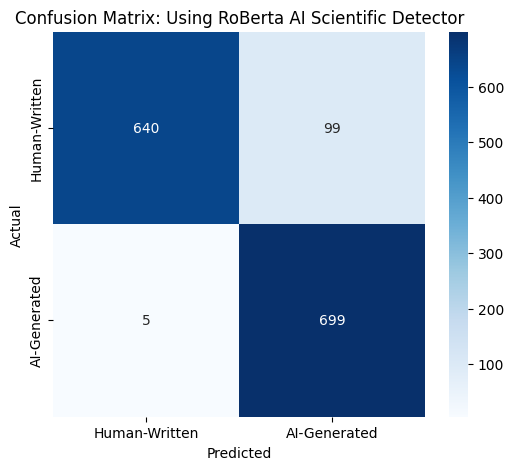

In [ ]:
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Using RoBerta AI Scientific Detector')
plt.show()